# Stage 05: Monte Carlo Simulation

Use Monte Carlo methods to generate probabilistic race predictions with confidence intervals.

**Method:** For each simulation run, we add stochastic noise to model predictions (calibrated from residuals), randomly apply DNFs, then re-rank to produce a simulated finishing order. Over 10,000 runs, this builds probability distributions for each driver.

This stage highlights **computational mathematics** skills: stochastic simulation, probability estimation, confidence intervals, and sensitivity analysis.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

from src.models import FEATURE_COLS, load_model
from src.simulation import (
    monte_carlo_race,
    generate_probabilities,
    build_position_matrix,
    sensitivity_analysis,
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 11
SAVE_DIR = '../outputs/figures/'

# Load the best model (Ridge) and feature data
model = load_model('../outputs/models/ridge_model.pkl')
features = pd.read_csv('../data/features/full_feature_matrix.csv')
print(f"Loaded Ridge model and feature matrix ({features.shape})")

Loaded Ridge model and feature matrix ((4626, 31))


## 5.1 Select Race to Simulate

We'll simulate the **2024 Abu Dhabi GP** (final race of the most recent season) as a demonstration, then validate against actual results.

In [2]:
# Get the last race of 2024
last_round = features[features['season'] == 2024]['round'].max()
race_data = features[(features['season'] == 2024) & (features['round'] == last_round)].copy()
race_name = f"2024 Round {last_round}"

driver_codes = race_data['driverCode'].tolist()
X_race = race_data[FEATURE_COLS].values
actual_positions = race_data['position'].values

print(f"Simulating: {race_name}")
print(f"Drivers: {len(driver_codes)}")
print(f"\nGrid order:")
for _, row in race_data.sort_values('grid').iterrows():
    print(f"  P{int(row['grid']):2d}: {row['driverCode']} ({row['constructorName']}) → Actual: P{int(row['position'])}")

Simulating: 2024 Round 24
Drivers: 20

Grid order:
  P 1: NOR (McLaren) → Actual: P1
  P 2: PIA (McLaren) → Actual: P10
  P 3: SAI (Ferrari) → Actual: P2
  P 4: VER (Red Bull) → Actual: P6
  P 5: GAS (Alpine F1 Team) → Actual: P7
  P 6: RUS (Mercedes) → Actual: P5
  P 7: HUL (Haas F1 Team) → Actual: P8
  P 8: ALO (Aston Martin) → Actual: P9
  P 9: BOT (Sauber) → Actual: P18
  P10: PER (Red Bull) → Actual: P20
  P11: TSU (RB F1 Team) → Actual: P12
  P12: LAW (RB F1 Team) → Actual: P17
  P13: STR (Aston Martin) → Actual: P14
  P14: MAG (Haas F1 Team) → Actual: P16
  P15: ZHO (Sauber) → Actual: P13
  P16: HAM (Mercedes) → Actual: P4
  P17: DOO (Alpine F1 Team) → Actual: P15
  P18: ALB (Williams) → Actual: P11
  P19: LEC (Ferrari) → Actual: P3
  P20: COL (Williams) → Actual: P19


## 5.2 Run Monte Carlo Simulation

**Parameters:**
- 10,000 simulation runs
- Noise std = 4.0 (calibrated from model residuals: std = 4.01)
- DNF probability = 5% per driver (historical average)

In [3]:
N_SIMS = 10000
NOISE_STD = 4.0
DNF_PROB = 0.05

sim_positions = monte_carlo_race(
    model, X_race, driver_codes,
    n_simulations=N_SIMS,
    noise_std=NOISE_STD,
    dnf_probability=DNF_PROB,
    random_state=42
)

print(f"Simulation complete: {sim_positions.shape[0]:,} runs x {sim_positions.shape[1]} drivers")
print(f"Position range: [{sim_positions.min()}, {sim_positions.max()}]")

Simulation complete: 10,000 runs x 20 drivers
Position range: [1, 20]


## 5.3 Probability Distributions

In [4]:
probs = generate_probabilities(sim_positions, driver_codes)

print(f"Race Outcome Probabilities ({race_name}):")
print(f"{'Driver':<8} {'E[Pos]':>6} {'Win%':>6} {'Podium%':>8} {'Points%':>8} {'90% CI':>12}")
print("-" * 54)
for _, row in probs.iterrows():
    ci = f"[{row['p5']:.0f}–{row['p95']:.0f}]"
    print(f"{row['driver']:<8} {row['expected_position']:6.1f} {row['win_prob']*100:5.1f}% {row['podium_prob']*100:7.1f}% {row['points_prob']*100:7.1f}% {ci:>12}")

Race Outcome Probabilities (2024 Round 24):
Driver   E[Pos]   Win%  Podium%  Points%       90% CI
------------------------------------------------------
VER         5.4  18.7%    46.4%    87.1%       [1–18]
NOR         5.5  18.9%    45.2%    86.6%       [1–18]
SAI         5.5  18.3%    45.6%    86.7%       [1–17]
PIA         6.0  14.5%    39.2%    83.8%       [1–18]
RUS         7.6   7.0%    23.8%    74.0%       [1–19]
HUL         9.0   4.0%    15.2%    63.4%       [2–19]
GAS         9.1   3.6%    14.8%    62.8%       [2–19]
LEC         9.3   3.3%    14.1%    60.9%       [2–19]
PER         9.3   3.5%    14.1%    61.2%       [2–19]
HAM         9.7   2.8%    11.9%    58.3%       [2–19]
ALO        10.9   1.6%     7.9%    47.6%       [3–19]
BOT        11.5   1.1%     5.4%    42.4%       [3–19]
TSU        12.2   0.7%     4.3%    36.2%       [4–20]
LAW        12.7   0.6%     3.2%    32.4%       [4–20]
MAG        13.1   0.5%     2.9%    28.8%       [5–20]
STR        13.2   0.4%     2.5%    27

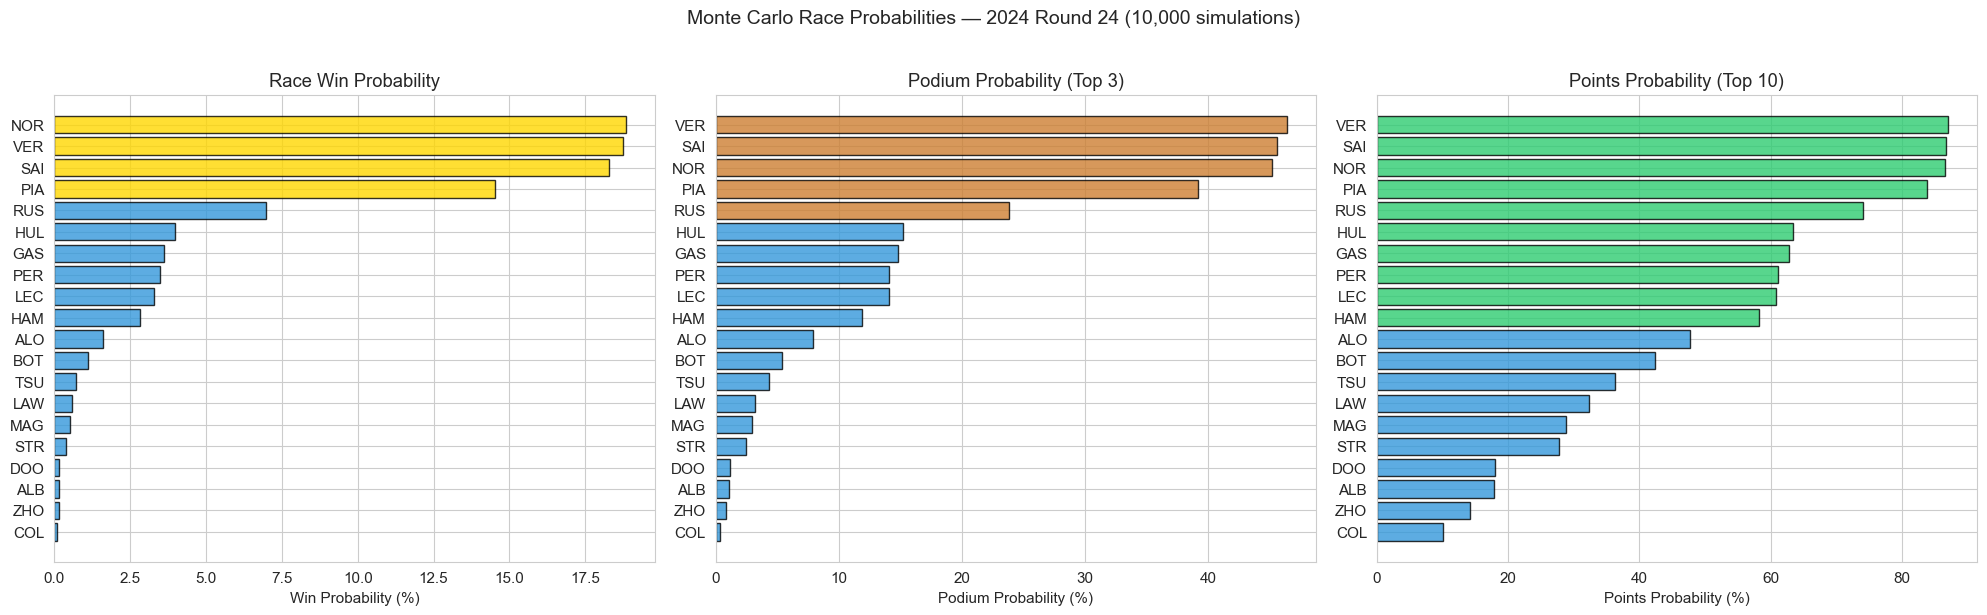

In [5]:
# Win probability bar chart
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

probs_sorted = probs.sort_values('win_prob', ascending=True)

# Win probability
colors_win = ['#FFD700' if p > 0.1 else '#3498db' for p in probs_sorted['win_prob']]
axes[0].barh(probs_sorted['driver'], probs_sorted['win_prob'] * 100, color=colors_win, edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Win Probability (%)')
axes[0].set_title('Race Win Probability')

# Podium probability
probs_sorted_pod = probs.sort_values('podium_prob', ascending=True)
colors_pod = ['#CD7F32' if p > 0.2 else '#3498db' for p in probs_sorted_pod['podium_prob']]
axes[1].barh(probs_sorted_pod['driver'], probs_sorted_pod['podium_prob'] * 100, color=colors_pod, edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Podium Probability (%)')
axes[1].set_title('Podium Probability (Top 3)')

# Points probability
probs_sorted_pts = probs.sort_values('points_prob', ascending=True)
colors_pts = ['#2ecc71' if p > 0.5 else '#3498db' for p in probs_sorted_pts['points_prob']]
axes[2].barh(probs_sorted_pts['driver'], probs_sorted_pts['points_prob'] * 100, color=colors_pts, edgecolor='black', alpha=0.8)
axes[2].set_xlabel('Points Probability (%)')
axes[2].set_title('Points Probability (Top 10)')

plt.suptitle(f'Monte Carlo Race Probabilities — {race_name} ({N_SIMS:,} simulations)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}mc_probabilities.png', dpi=150, bbox_inches='tight')
plt.show()

## 5.4 Position Probability Heatmap

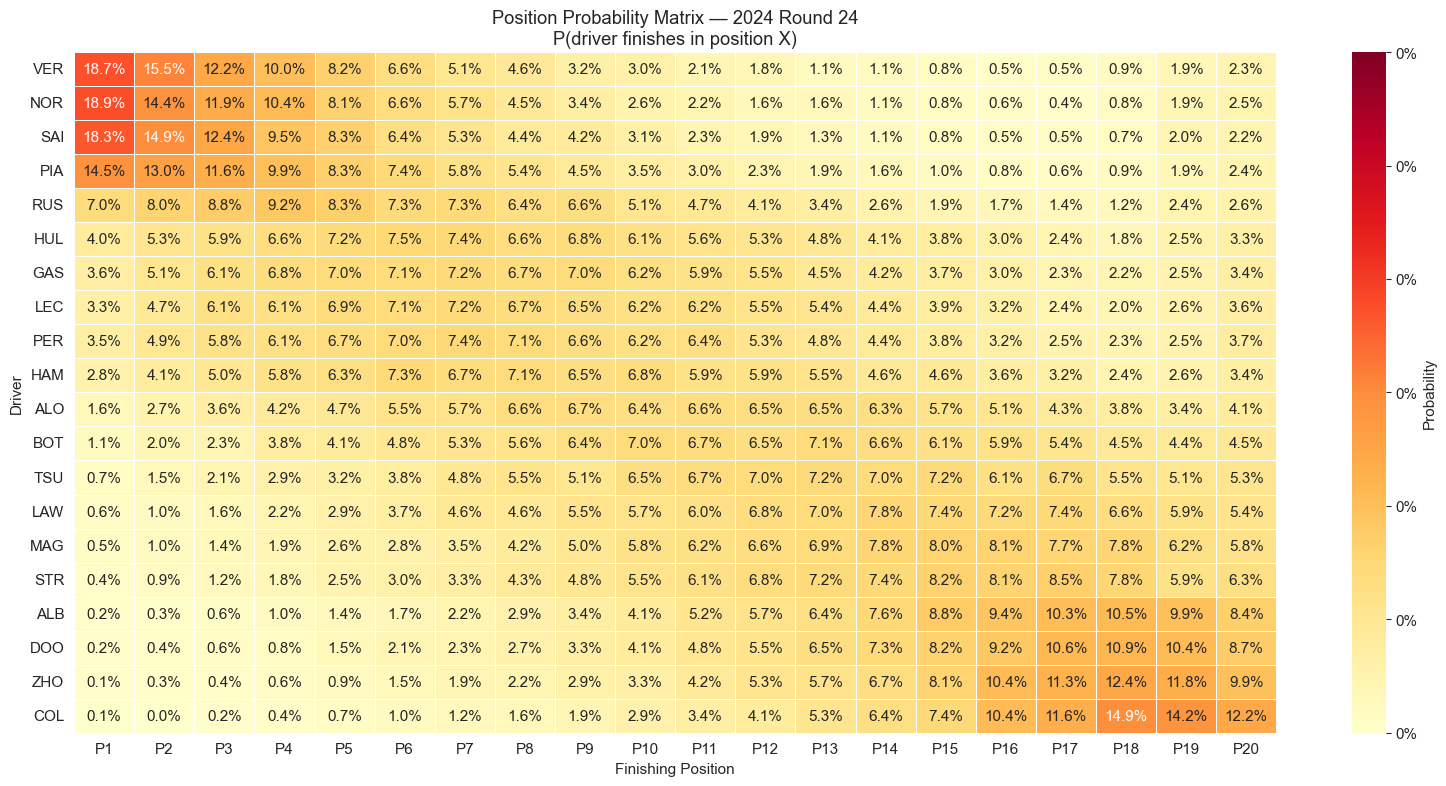

In [6]:
pos_matrix = build_position_matrix(sim_positions, driver_codes)

# Reorder rows by expected position
row_order = probs.sort_values('expected_position')['driver'].tolist()
pos_matrix = pos_matrix.loc[row_order]

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(pos_matrix, annot=True, fmt='.1%', cmap='YlOrRd', ax=ax,
            linewidths=0.5, vmin=0, vmax=0.3,
            cbar_kws={'label': 'Probability', 'format': '%.0f%%'})
ax.set_xlabel('Finishing Position')
ax.set_ylabel('Driver')
ax.set_title(f'Position Probability Matrix — {race_name}\nP(driver finishes in position X)')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}mc_position_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 5.5 Confidence Intervals & Validation

C:\Users\brian\AppData\Local\Temp\ipykernel_22368\1876549656.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=order, vert=True, patch_artist=True,


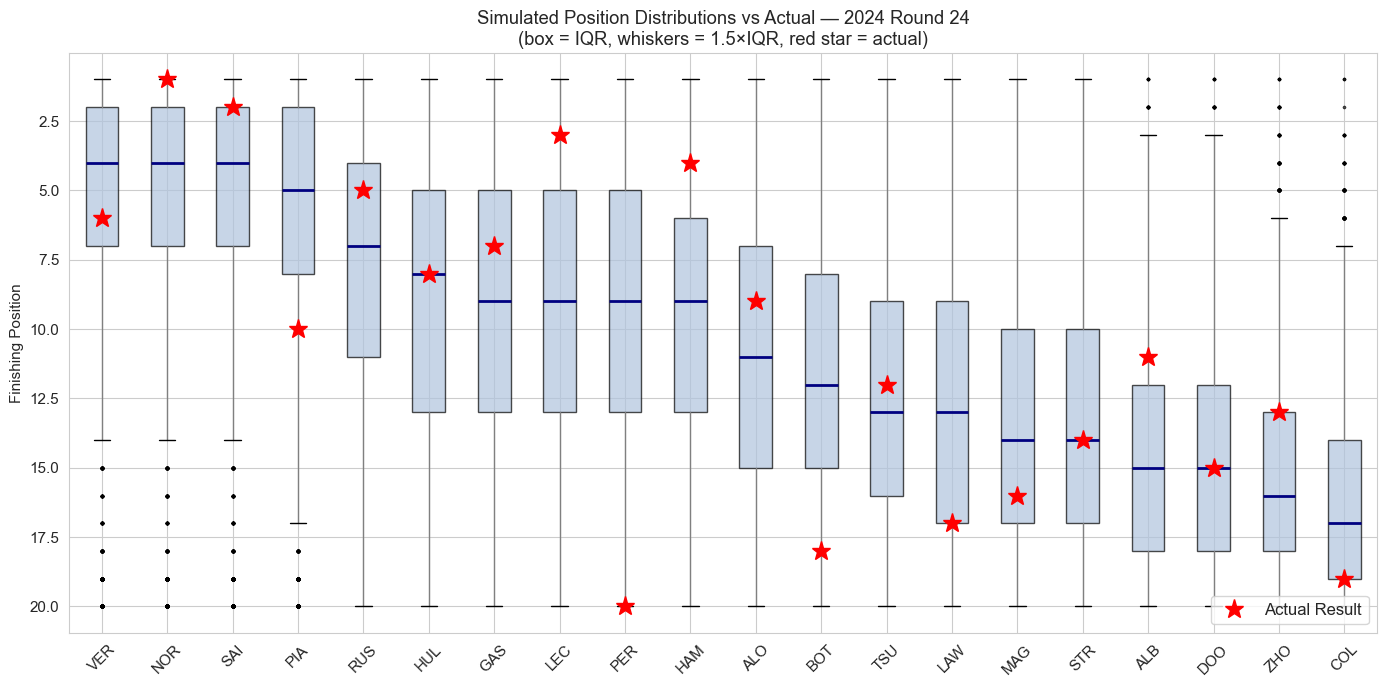


90% CI coverage: 19/20 drivers (95%)
(Expected ~90% if well-calibrated)


In [7]:
# Box plot of simulated positions with actual results overlaid
order = probs.sort_values('expected_position')['driver'].tolist()

fig, ax = plt.subplots(figsize=(14, 7))

# Build data for box plot
box_data = []
for driver in order:
    j = driver_codes.index(driver)
    box_data.append(sim_positions[:, j])

bp = ax.boxplot(box_data, labels=order, vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightsteelblue', alpha=0.7),
                medianprops=dict(color='navy', linewidth=2),
                whiskerprops=dict(color='gray'),
                flierprops=dict(marker='.', alpha=0.3, markersize=3))

# Overlay actual positions
actual_map = dict(zip(race_data['driverCode'], race_data['position']))
for i, driver in enumerate(order):
    actual = actual_map[driver]
    ax.plot(i + 1, actual, 'r*', markersize=14, zorder=5)

ax.plot([], [], 'r*', markersize=14, label='Actual Result')
ax.legend(loc='lower right', fontsize=12)

ax.set_ylabel('Finishing Position')
ax.set_title(f'Simulated Position Distributions vs Actual — {race_name}\n(box = IQR, whiskers = 1.5×IQR, red star = actual)')
ax.invert_yaxis()
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}mc_confidence_intervals.png', dpi=150, bbox_inches='tight')
plt.show()

# Validation: how often does actual position fall within 90% CI?
in_ci = 0
for _, row in probs.iterrows():
    actual = actual_map[row['driver']]
    if row['p5'] <= actual <= row['p95']:
        in_ci += 1

print(f"\n90% CI coverage: {in_ci}/{len(probs)} drivers ({in_ci/len(probs):.0%})")
print(f"(Expected ~90% if well-calibrated)")

## 5.6 Sensitivity Analysis

How much do predictions change when we vary key input features? We test `grid` (qualifying position) and `team_rolling_points` (team strength).

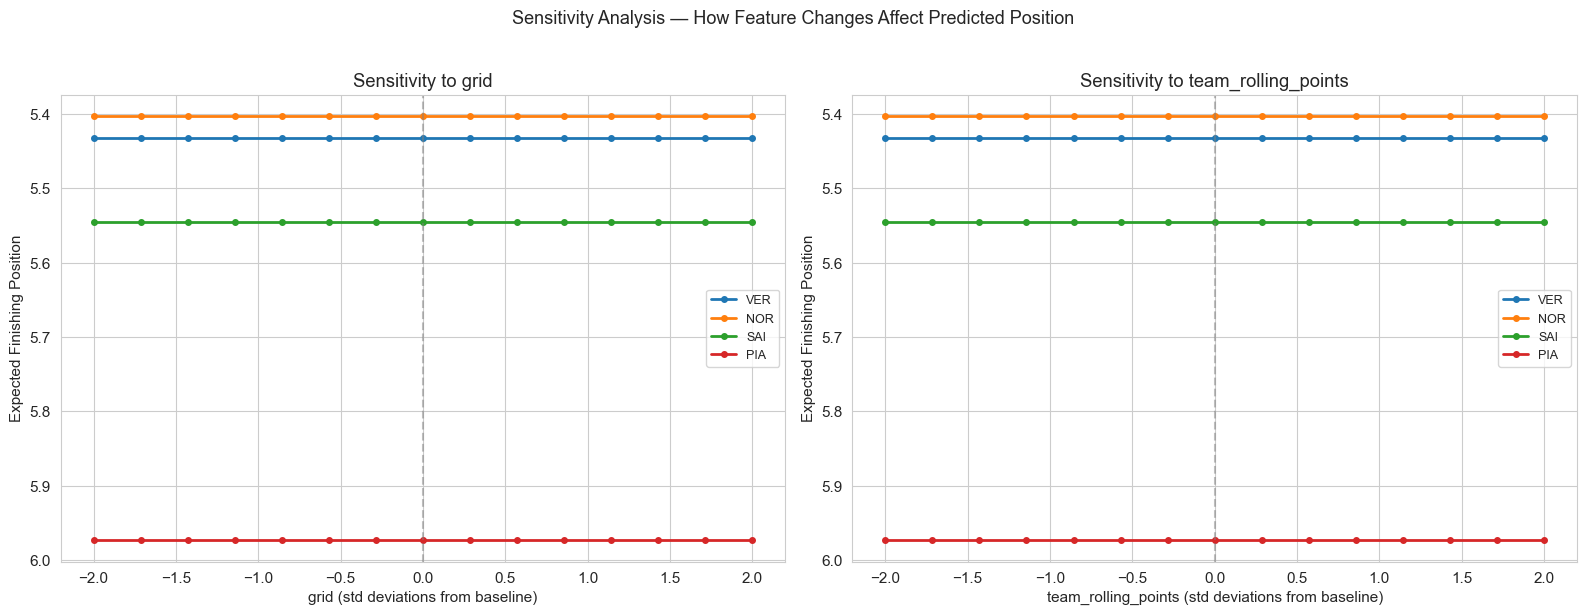

In [8]:
# Sensitivity: grid position
grid_idx = FEATURE_COLS.index('grid')
team_pts_idx = FEATURE_COLS.index('team_rolling_points')

# Pick top 4 drivers for clarity
top_4 = probs.head(4)['driver'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, feat_idx, feat_name in [(axes[0], grid_idx, 'grid'),
                                  (axes[1], team_pts_idx, 'team_rolling_points')]:
    sens_df = sensitivity_analysis(
        model, X_race, driver_codes, FEATURE_COLS,
        feature_idx=feat_idx, vary_range=(-2, 2), n_steps=15,
        n_simulations=3000, noise_std=NOISE_STD
    )

    for driver in top_4:
        d = sens_df[sens_df['driver'] == driver]
        ax.plot(d['feature_value_norm'], d['expected_position'], marker='o', label=driver, linewidth=2, markersize=4)

    ax.set_xlabel(f'{feat_name} (std deviations from baseline)')
    ax.set_ylabel('Expected Finishing Position')
    ax.set_title(f'Sensitivity to {feat_name}')
    ax.invert_yaxis()
    ax.legend(fontsize=9)
    ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)

plt.suptitle('Sensitivity Analysis — How Feature Changes Affect Predicted Position', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}mc_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

## 5.7 Multi-Race Simulation (Season Validation)

In [9]:
# Simulate all 2024 races and check coverage
coverage_results = []

for rnd in sorted(features[features['season'] == 2024]['round'].unique()):
    rd = features[(features['season'] == 2024) & (features['round'] == rnd)].copy()
    rd = rd.dropna(subset=FEATURE_COLS)
    if len(rd) == 0:
        continue

    codes = rd['driverCode'].tolist()
    X = rd[FEATURE_COLS].values
    actuals = dict(zip(rd['driverCode'], rd['position']))

    sim = monte_carlo_race(model, X, codes, n_simulations=5000,
                           noise_std=NOISE_STD, dnf_probability=DNF_PROB,
                           random_state=rnd)
    p = generate_probabilities(sim, codes)

    for _, row in p.iterrows():
        actual = actuals[row['driver']]
        coverage_results.append({
            'round': rnd,
            'driver': row['driver'],
            'expected_pos': row['expected_position'],
            'actual_pos': actual,
            'error': abs(row['expected_position'] - actual),
            'in_90ci': row['p5'] <= actual <= row['p95'],
            'in_50ci': row['p25'] <= actual <= row['p75'],
        })

cov_df = pd.DataFrame(coverage_results)

print(f"2024 Season Simulation Validation ({len(cov_df)} driver-race entries):")
print(f"  Mean absolute error: {cov_df['error'].mean():.2f} positions")
print(f"  Median absolute error: {cov_df['error'].median():.2f} positions")
print(f"  90% CI coverage: {cov_df['in_90ci'].mean():.1%} (target: 90%)")
print(f"  50% CI coverage: {cov_df['in_50ci'].mean():.1%} (target: 50%)")

2024 Season Simulation Validation (479 driver-race entries):
  Mean absolute error: 2.96 positions
  Median absolute error: 2.50 positions
  90% CI coverage: 97.9% (target: 90%)
  50% CI coverage: 72.4% (target: 50%)


## 5.8 Save Simulation Results

In [10]:
# Save single-race probabilities
probs.to_csv('../outputs/predictions/simulation_probabilities.csv', index=False)
print(f"Saved simulation probabilities ({len(probs)} drivers)")

# Save position matrix
pos_matrix.to_csv('../outputs/predictions/position_probability_matrix.csv')
print("Saved position probability matrix")

# Save season validation
cov_df.to_csv('../outputs/predictions/season_simulation_validation.csv', index=False)
print(f"Saved season validation ({len(cov_df)} entries)")

print(f"\nAll simulation outputs saved. Figures in {SAVE_DIR}")

Saved simulation probabilities (20 drivers)
Saved position probability matrix
Saved season validation (479 entries)

All simulation outputs saved. Figures in ../outputs/figures/
